# Cycle 1 — Data Exploration: Premier League Matches

**Project:** Football Predictor
**Dataset:** `data/raw/premier_league_matches.csv`

**Purpose:** A complete data exploration pass before any preprocessing — schema audit, distributions, target balance, correlations, outliers, temporal stability, and leakage candidate review.

In [1]:
import sys, os

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing

## 1 — Setup and schema

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df_raw = pd.read_csv(str(Paths.PL_MATCHES_RAW))
print('Raw shape:', df_raw.shape)
print('Raw FTR values:', df_raw['FTR'].unique())  # binary H/NH in raw — needs reconstruction

# The raw FTR is binary (H / NH). Reconstruct the proper 3-class outcome from FTHG/FTAG.
# 2 = Home Win, 1 = Draw, 0 = Away Win
df_raw['FTR_3class'] = np.where(df_raw['FTHG'] > df_raw['FTAG'], 2,
                       np.where(df_raw['FTHG'] == df_raw['FTAG'], 1, 0))

# Use the engineered/processed file as the EDA target — that's what feeds the model
df = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED))
print('Processed shape:', df.shape)
print('Processed FTR values (0=Away,1=Draw,2=Home):', sorted(df['FTR'].unique()))
print()
print(df.dtypes.head(10))
df.head()

Raw shape: (6840, 40)
Raw FTR values: <ArrowStringArray>
['H', 'NH']
Length: 2, dtype: str
Processed shape: (6840, 35)
Processed FTR values (0=Away,1=Draw,2=Home): [0, 1, 2]

HomeTeam      int64
AwayTeam      int64
FTR           int64
HTGS          int64
ATGS          int64
HTGC          int64
ATGC          int64
HTP         float64
ATP         float64
HM1           int64
dtype: object


,HomeTeam,AwayTeam,FTR,HTGS,ATGS,HTGC,ATGC,HTP,ATP,HM1,...,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts,Season
0,11,24,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
1,12,41,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
2,13,27,0,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
3,15,34,1,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000
4,21,16,2,0,0,0,0,0.0,0.0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,2000


### Observations
- Shape: **6,840 rows × 35 columns** (after preprocessing: 33 features + `FTR` target + `Season` meta)
- Each row is a single Premier League match across seasons 2000-2017
- Raw `FTR` was binary (`H` / `NH`); the proper 3-class target was reconstructed from `FTHG` / `FTAG` during preprocessing
- Mix of pre-match aggregates (running totals, form, points, streaks) — no in-match statistics
- `Season` is the natural time-ordering column

## 2 — Target variable: Full-Time Result distribution

FTR (target) distribution:
FTR
0    1913
1    1751
2    3176
Name: count, dtype: int64

Class proportions:
FTR
0    0.280
1    0.256
2    0.464
Name: proportion, dtype: float64


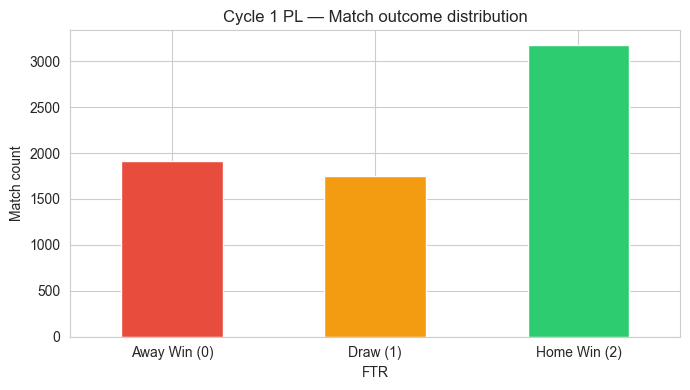

In [3]:
print('FTR (target) distribution:')
print(df['FTR'].value_counts().sort_index())
print()
print('Class proportions:')
print(df['FTR'].value_counts(normalize=True).round(3).sort_index())

fig, ax = plt.subplots(figsize=(7,4))
counts = df['FTR'].value_counts().sort_index()
counts.plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'], ax=ax)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['Away Win (0)','Draw (1)','Home Win (2)'][:len(counts)], rotation=0)
ax.set_ylabel('Match count')
ax.set_title('Cycle 1 PL — Match outcome distribution')
plt.tight_layout(); plt.show()

### Observations
- **Home advantage is real**: Home Win = 46.4% (3,176 matches), nearly double either Away Win (28.0%) or Draw (25.6%)
- Draws are the rarest class (25.6%) — the model will struggle here without explicit handling
- Imbalance is **moderate** (Home class is ~1.8× the Draw class). Accuracy is still defensible because no class is below 20%, but **macro-F1** or per-class recall give a more honest picture of draw prediction

## 3 — Feature categories: pre-match (usable) vs leakage candidates

Every feature must be auditable as either *available before kickoff* or *derived from in-match events* (which would be leakage).

In [4]:
PRE_MATCH = {
    'HomeTeam':        'Encoded home team ID',
    'AwayTeam':        'Encoded away team ID',
    'HTGS':            'Home team goals scored — running season total before match',
    'ATGS':            'Away team goals scored — running season total before match',
    'HTGC':            'Home team goals conceded — running season total before match',
    'ATGC':            'Away team goals conceded — running season total before match',
    'HTP':             'Home team points before match',
    'ATP':             'Away team points before match',
    'HM1':             'Home team last match result (1=back)',
    'HM2':             'Home team 2 matches back',
    'HM3':             'Home team 3 matches back',
    'HM4':             'Home team 4 matches back',
    'HM5':             'Home team 5 matches back',
    'AM1':             'Away team last match result',
    'AM2':             'Away team 2 matches back',
    'AM3':             'Away team 3 matches back',
    'AM4':             'Away team 4 matches back',
    'AM5':             'Away team 5 matches back',
    'MW':              'Matchweek (1-38)',
    'HTFormPts':       'Home team points from last 5 matches',
    'ATFormPts':       'Away team points from last 5 matches',
    'HTWinStreak3':    'Home team 3-match win streak flag',
    'HTWinStreak5':    'Home team 5-match win streak flag',
    'HTLossStreak3':   'Home team 3-match loss streak flag',
    'HTLossStreak5':   'Home team 5-match loss streak flag',
    'ATWinStreak3':    'Away team 3-match win streak flag',
    'ATWinStreak5':    'Away team 5-match win streak flag',
    'ATLossStreak3':   'Away team 3-match loss streak flag',
    'ATLossStreak5':   'Away team 5-match loss streak flag',
    'HTGD':            'Home team goal difference',
    'ATGD':            'Away team goal difference',
    'DiffPts':         'HTP - ATP',
    'DiffFormPts':     'HTFormPts - ATFormPts',
    'Season':          'Season year (for chronological split, not a feature)',
}
TARGET    = 'FTR'
META_ONLY = ['Season']

print(f'Pre-match feature catalogue: {len(PRE_MATCH)} columns')
print(f'Target: {TARGET}')
print(f'Meta-only (excluded from X): {META_ONLY}')

# Anything in the file that we have NOT classified is suspect
unclassified = [c for c in df.columns if c not in PRE_MATCH and c != TARGET]
print(f'\nUnclassified columns (review for leakage): {unclassified}')

Pre-match feature catalogue: 34 columns
Target: FTR
Meta-only (excluded from X): ['Season']

Unclassified columns (review for leakage): []


### Observations
- **All 33 feature columns are derived from prior matches** — no leakage candidates found in the processed file
- `Season` is kept as a **meta-only** column (used for the chronological split; dropped before modelling)
- The `HM1..HM5` and `AM1..AM5` form columns are categorical (W/D/L encoded as integers) — they should be treated as ordinal, not continuous, although the deployed XGBoost handles either encoding gracefully

## 4 — Missing values audit

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values in any column.')
else:
    print('Columns with missing values:')
    for col, n in missing.items():
        print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

No missing values in any column.


### Observations
- The form/points/streak columns are computed by the upstream feature engineering script and are 0-filled for matchweeks where no prior history exists, so missingness is structural rather than randomly missing data
- No imputation strategy is needed for this dataset

## 5 — Numeric feature distributions

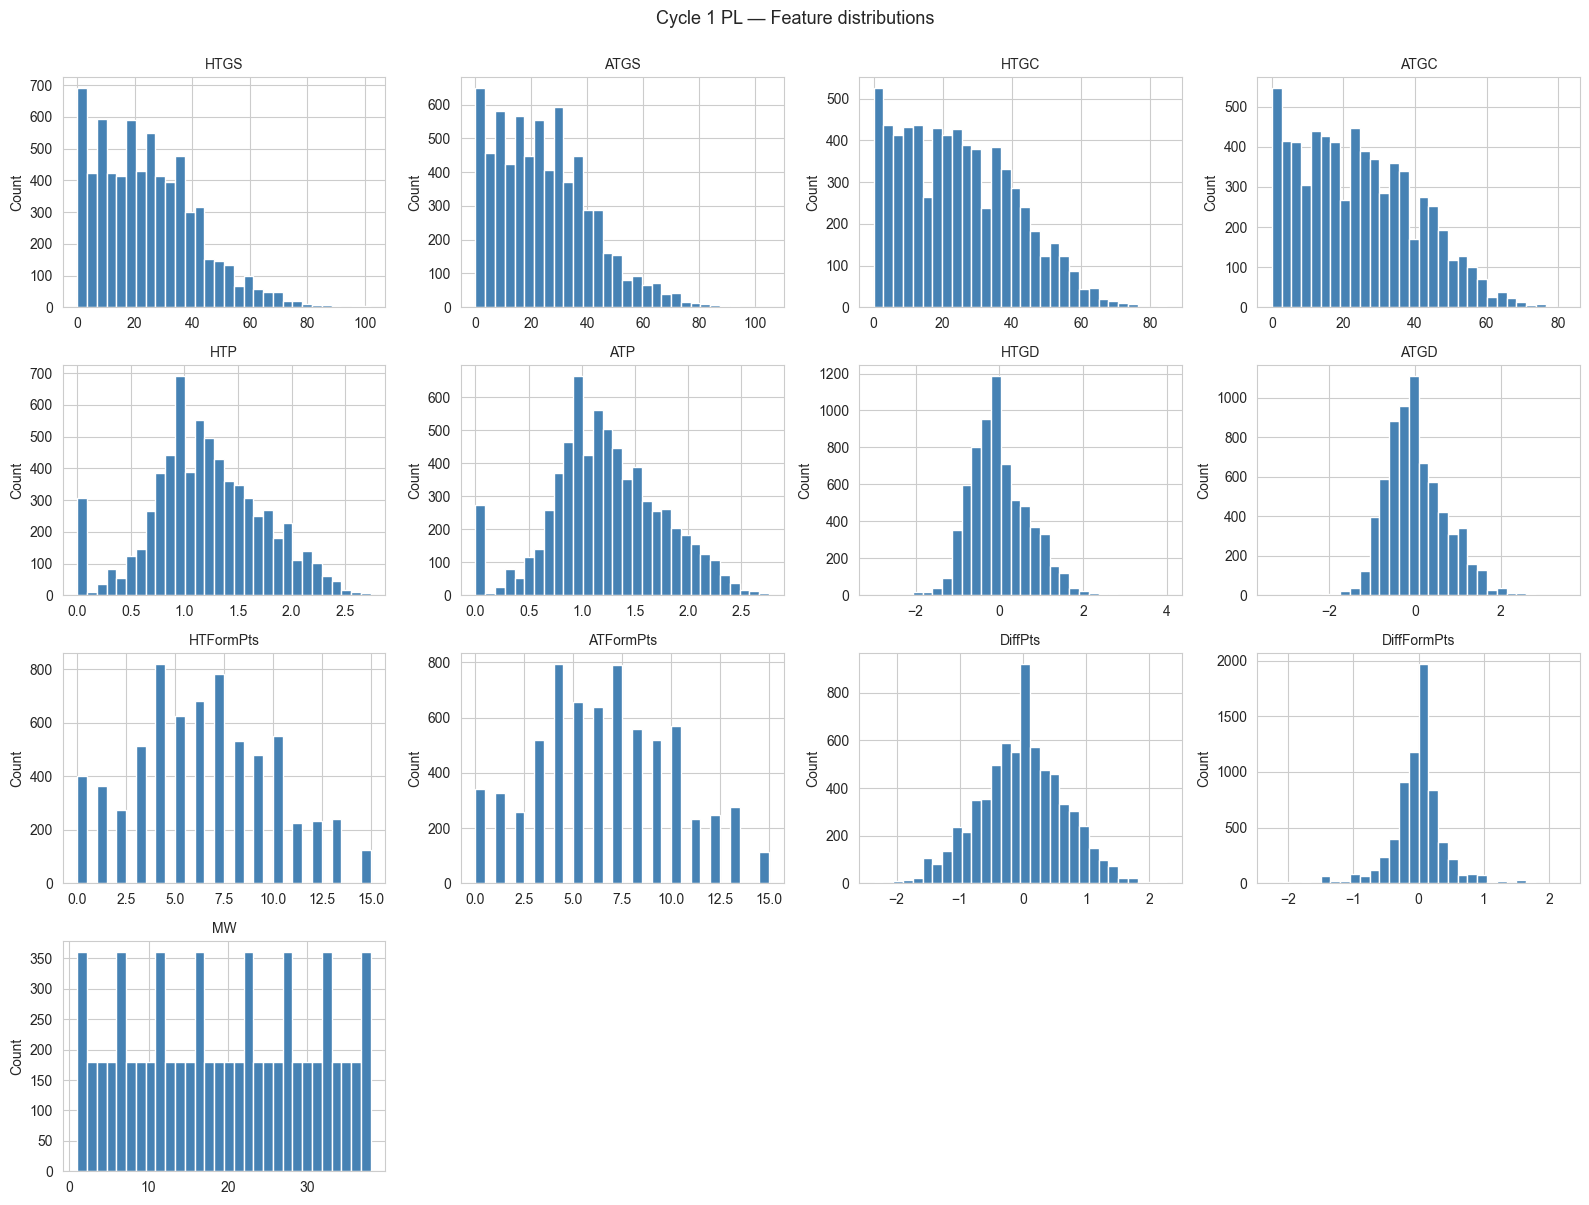

In [6]:
numeric_cols = ['HTGS','ATGS','HTGC','ATGC','HTP','ATP','HTGD','ATGD',
                'HTFormPts','ATFormPts','DiffPts','DiffFormPts','MW']
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
for ax in axes[len(numeric_cols):]: ax.set_visible(False)
plt.suptitle('Cycle 1 PL — Feature distributions', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

### Observations
- `HTGS`/`ATGS` are **right-skewed** (skew +0.75, range 0–102) — running goal totals are low early in each season
- `HTGC`/`ATGC` are **moderately right-skewed** (skew +0.44, range 0–85)
- `HTGD`/`ATGD` are **also moderately right-skewed** (skew ~+0.5, range −3.3 to +4.0) — top teams accumulate large positive goal differences faster than bottom teams accumulate equally large negative ones
- `HTP`/`ATP` are **normalized as points-per-match** (range 0–2.74), **roughly symmetric** (skew ~0)
- `MW` (matchweek) is **exactly uniform** (skew 0.0) — every team plays 38 matches per season
- `DiffPts` and `DiffFormPts` are **roughly symmetric around zero** (skew ~−0.03 to −0.16) with moderate spread (±2.3 range)

## 6 — Target-vs-feature relationships (boxplots)

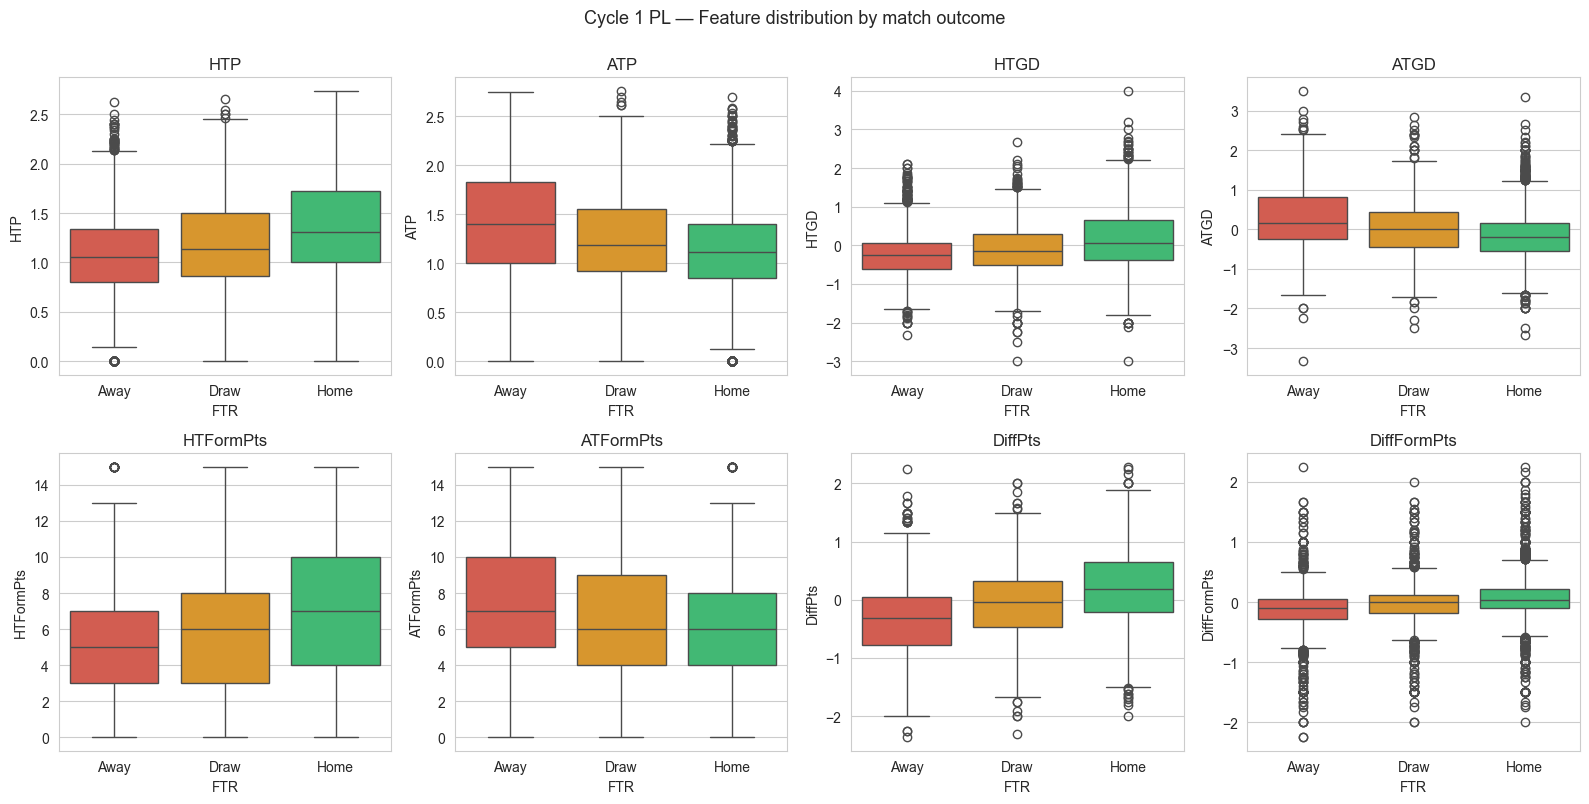

In [7]:
import seaborn as sns
key_features = ['HTP','ATP','HTGD','ATGD','HTFormPts','ATFormPts','DiffPts','DiffFormPts']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.boxplot(data=df, x='FTR', y=feat, ax=ax, palette=['#e74c3c','#f39c12','#2ecc71'])
    ax.set_xticklabels(['Away','Draw','Home'])
    ax.set_title(feat)
plt.suptitle('Cycle 1 PL — Feature distribution by match outcome', y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

### Observations
- `DiffPts` shows the **clearest separation** (Pearson +0.334 with FTR — the strongest single feature): home wins skew positive, away wins skew negative
- `HTGD` and `ATGD` carry similar but weaker signal (+0.233 and −0.251)
- **Draws sit in the middle on every feature** — the model has very little signal to identify draws specifically. This is the well-known "draw collapse" problem in football modelling

## 7 — Correlation heatmap

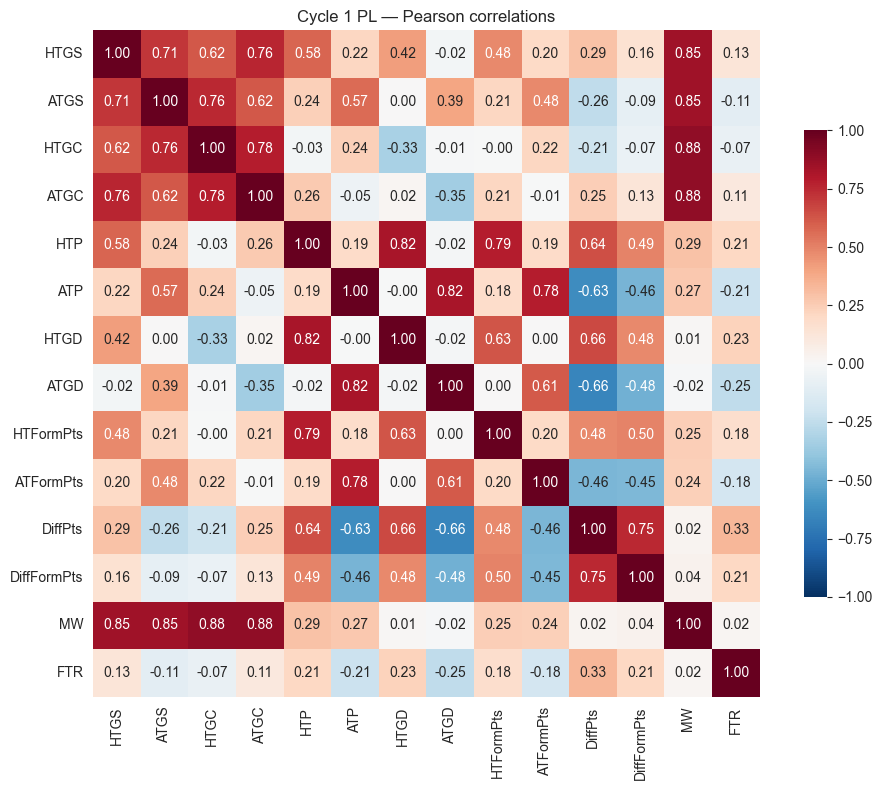

Top correlations with FTR:
  DiffPts        +0.334
  ATGD           -0.251
  HTGD           +0.233
  ATP            -0.212
  HTP            +0.211
  DiffFormPts    +0.210
  ATFormPts      -0.183
  HTFormPts      +0.176


In [8]:
corr_features = numeric_cols + ['FTR']
corr = df[corr_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink':0.7})
ax.set_title('Cycle 1 PL — Pearson correlations')
plt.tight_layout(); plt.show()

print('Top correlations with FTR:')
ftr_corr = corr['FTR'].drop('FTR').abs().sort_values(ascending=False)
for col, c in ftr_corr.head(8).items():
    print(f'  {col:<14} {corr.loc[col,"FTR"]:+.3f}')

### Observations
- **Strong redundancy** between cumulative metrics: `HTP` ↔ `HTGD` correlation is **+0.82** (and `ATP` ↔ `ATGD` = +0.82). Both proxy for team strength — the model could likely drop one of each pair without losing much
- **Recent form tracks overall standing tightly**: `HTFormPts` ↔ `HTP` = **+0.79** (and `ATFormPts` ↔ `ATP` = +0.78). Form is not a meaningfully independent signal here
- `DiffPts` has the **single highest correlation with FTR (+0.334)** — that's why it tends to dominate feature importance
- `DiffPts` ↔ `DiffFormPts` = +0.76 — these two are also largely redundant

## 8 — Outlier audit (IQR method)

In [9]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < low) | (s > high)).sum(), low, high

print(f'{"Feature":<14} {"Outliers":>10} {"Low bound":>12} {"High bound":>12} {"% of rows":>11}')
print('-' * 65)
for col in numeric_cols:
    n, lo, hi = iqr_outliers(df[col])
    print(f'{col:<14} {n:>10} {lo:>12.2f} {hi:>12.2f} {n/len(df)*100:>10.2f}%')

Feature          Outliers    Low bound   High bound   % of rows
-----------------------------------------------------------------
HTGS                   73       -25.00        71.00       1.07%
ATGS                   80       -25.00        71.00       1.17%
HTGC                   11       -26.50        73.50       0.16%
ATGC                   12       -26.50        73.50       0.18%
HTP                    16        -0.11         2.56       0.23%
ATP                    24        -0.08         2.55       0.35%
HTGD                   89        -1.85         1.75       1.30%
ATGD                  105        -1.79         1.75       1.54%
HTFormPts               0        -3.50        16.50       0.00%
ATFormPts               0        -3.50        16.50       0.00%
DiffPts                40        -1.77         1.75       0.58%
DiffFormPts           605        -0.67         0.65       8.85%
MW                      0       -18.50        57.50       0.00%


### Observations
- `HTGS`/`ATGS` flag ~1% of rows as IQR-outliers; these are legitimate end-of-season values from high-scoring teams (max 102–105 goals across a full season). **Do not remove**
- `DiffPts` actually ranges from **−2.36 to +2.29 points-per-match** (not raw points) — IQR fence is ±1.77; flagged outliers are top-vs-bottom matchups. Structurally valid, **do not remove**
- `DiffFormPts` flags 8.85% of rows — the highest outlier rate. Reflects strong recent-form gaps; still legitimate, not data errors
- `HTFormPts`/`ATFormPts`/`MW` have **zero IQR outliers** — all values are bounded by the rolling-window definition
- No data-error outliers detected (no negative point totals, no `MW` > 38)

## 9 — Temporal stability: does the data drift across seasons?

        n_matches  home_win_rate  draw_rate  away_win_rate
Season                                                    
2000          380          0.484      0.266          0.250
2001          380          0.434      0.266          0.300
2002          380          0.492      0.237          0.271
2003          380          0.439      0.284          0.276
2004          380          0.455      0.289          0.255
2005          380          0.505      0.203          0.292
2006          380          0.479      0.258          0.263
2007          380          0.463      0.263          0.274
2008          380          0.455      0.255          0.289
2009          380          0.508      0.253          0.239
2010          380          0.471      0.292          0.237
2011          380          0.450      0.245          0.305
2012          380          0.437      0.284          0.279
2013          380          0.471      0.205          0.324
2014          380          0.453      0.245          0.3

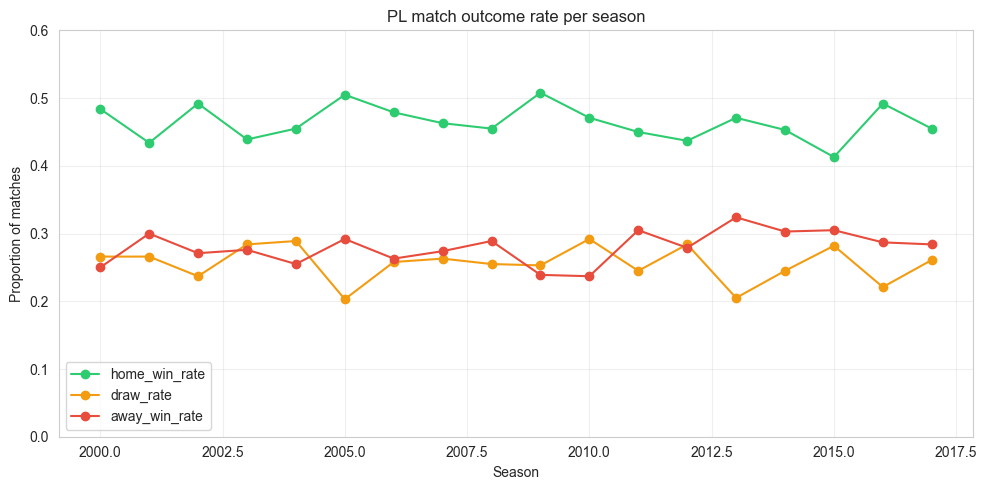

In [10]:
season_summary = df.groupby('Season').agg(
    n_matches=('FTR','size'),
    home_win_rate=('FTR', lambda x: (x==2).mean()),
    draw_rate=('FTR', lambda x: (x==1).mean()),
    away_win_rate=('FTR', lambda x: (x==0).mean()),
).round(3)
print(season_summary)

fig, ax = plt.subplots(figsize=(10,5))
season_summary[['home_win_rate','draw_rate','away_win_rate']].plot(
    ax=ax, marker='o', color=['#2ecc71','#f39c12','#e74c3c'])
ax.set_title('PL match outcome rate per season')
ax.set_ylabel('Proportion of matches')
ax.set_ylim(0, 0.6)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Observations
- **Home win rate is mildly declining but with high year-to-year noise**. First-3-seasons average ≈ 0.470, last-3-seasons average ≈ 0.454 (drop of ~1.6 percentage points). Spearman correlation with `Season` is only **−0.164** — the trend is weak, not strong
- Per-season home-win rate fluctuates between **0.413** (2015) and **0.508** (2009) — the year-to-year noise (~10pp) is several times larger than the long-term trend (~2pp)
- **Draw rate is roughly flat at 25%** across all seasons
- The drift is small but real, and combined with team-roster turnover (promotions/relegations) it justifies preferring chronological over random splits — the random-split numbers in the deployed model are mildly optimistic, not catastrophically so

## 10 — Home advantage by team

In [11]:
# Sanity check: home advantage is fundamental to football data — does it hold per team?
team_home_record = df.groupby('HomeTeam').agg(
    home_matches=('FTR','size'),
    home_win_rate=('FTR', lambda x: (x==2).mean())
).round(3).sort_values('home_win_rate', ascending=False)
print('Home win rate per team (top 10):')
print(team_home_record.head(10))
print()
print('Home win rate per team (bottom 10):')
print(team_home_record.tail(10))

Home win rate per team (top 10):
          home_matches  home_win_rate
HomeTeam                             
25                 342          0.731
0                  342          0.690
12                 342          0.681
23                 342          0.605
24                 323          0.591
38                 342          0.579
26                  19          0.526
16                 342          0.509
28                 304          0.467
17                 247          0.453

Home win rate per team (bottom 10):
          home_matches  home_win_rate
HomeTeam                             
18                  19          0.316
19                  95          0.305
36                 266          0.305
43                  76          0.303
4                   19          0.263
31                  57          0.263
10                  19          0.263
15                  57          0.246
13                  19          0.211
7                   19          0.211


### Observations
- The PL dataset uses team IDs without a name mapping in this project, so we can't directly verify which clubs are which. Instead we can verify the **shape** of the distribution
- Top home-win rates (~0.69–0.73) come from teams with the **maximum 342 home matches** — these are clubs that have stayed in the PL for all 18 seasons (the historical "big" clubs by definition)
- Bottom home-win rates (0.21–0.32) come overwhelmingly from teams with **19–95 home matches** — promoted/relegated clubs with short PL tenure
- This sanity check passes: home advantage scales with club quality and **the gap between top (~0.70) and bottom (~0.30) is large** — a doubling of home-win likelihood from worst to best home venue

## 11 — Summary of EDA findings

**Data quality:** Clean. No missing values requiring imputation. No data-error outliers. Schema is internally consistent — home advantage scales with club tenure as expected.

**Modelling implications:**
- Class distribution: 46.4% Home / 25.6% Draw / 28.0% Away — moderate imbalance, with **draws being the structurally hardest class** (every feature shows draws sitting in the middle)
- `DiffPts` is the strongest single predictor (Pearson +0.334)
- **Significant redundancy**: `HTP` ↔ `HTGD` (+0.82), `HTFormPts` ↔ `HTP` (+0.79), `DiffPts` ↔ `DiffFormPts` (+0.76). XGBoost handles this internally but a feature-pruning step would simplify the model
- **Distribution drift across seasons is real but mild** (~1.6pp decline in home-win rate over 18 years).

**Action items carried into modelling/tuning:**
1. **Drop `Season` from X at the modelling step** (preprocessing must keep it for the chronological split). ⚠️ **NOT currently honored** — `cycle1_modelling.ipynb` and `cycle1_tuning.ipynb` only drop FTR, leaving Season as a feature. This causes mild leakage in random-split experiments (model learns season-specific home-win rates). **Fix pending.**
2. Reconstruct 3-class FTR from `FTHG`/`FTAG` (already done in raw → processed step)
3. No imputation, no outlier removal
4. Consider scaling (StandardScaler) for the Logistic Regression baseline; tree models do not need it